# Машинное обучение, ФКН ВШЭ

# Практическое задание 6. Бустинговое

## Общая информация

Дата выдачи: 11.05.2026

Мягкий дедлайн: 25.05.2026 23:59 MSK

Жёсткий дедлайн: 31.05.2026 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-06-Username.ipynb
* Модуль boosting.py

Username — ваша фамилия на латинице

## О задании

В этом задании вам предстоит вручную запрограммировать один из самых мощных алгоритмов машинного обучения — бустинг. Однако с большой силой приходит и большая ответственность, поэтому придется научиться им пользоваться

In [1]:
from warnings import filterwarnings

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set(style='darkgrid')
filterwarnings('ignore')

Мы будем работать с датасетом по предсказанию гендера. Никакие фичи мы придумывать не будем, но если вам интересно, в датасете имеется:

- region — регион, в котором проводили опрос
- age — возраст опрошенного
- year — год опроса
- race — этническая принадлежность
- sch — количество классов образования
- empstat — статус трудоустройства
- occ — код профессии
- ind — код индустрии, в которой человек работает
- annhrs — число часов работы в год
- hrwage — почасовая оплата
- icwage — суммарная оплата в год
- occupation — должность

Целевая метрика ROC-AUC, потому что мы непритязательны и это не фокус этой домашки



In [2]:
import pyarrow.parquet as pq

table = pq.read_table("hw6_dataset.pq", arrow_extensions_enabled=False)
df = table.to_pandas()
X = df.drop("sex", axis=1)
y = df["sex"]

Пока что мы временно выкинем колонку с должностью, но мы к ней обязательно вернемся

Разделим на обучающую, валидационную и тестовую выборки по годам, чтобы предсказывать будущее, а не прошлое

In [3]:
X_train = X[X["year"] < 2011].drop("occupation", axis=1).values
y_train = y[X["year"] < 2011].values

X_valid = X[X["year"] == 2011].drop("occupation", axis=1).values
y_valid = y[X["year"] == 2011].values

X_test = X[X["year"] == 2013].drop("occupation", axis=1).values
y_test = y[X["year"] == 2013].values

X_train.shape, X_valid.shape, X_test.shape

((236640, 10), (53857, 10), (53790, 10))

Домашнее задание имеет нелинейную структуру. В нём есть <font color='lightcoral'>📌 **обязательные**</font> части, без которых будет тяжко <font color='lightcoral'>**(6 баллов)**</font>, и целая куча 💠 **опциональных**, которыми можно добить оценку до 10, делайте то, что нравится больше! **Музыкальный бонус** идёт отдельно, за него можно получить ещё 0.5 балла.

---

## 📌 Задание 1. Базовый градиентный бустинг (4 балла)

Это задание <font color='lightcoral'>**📌 обязательное**</font>, без него домашка не имеет смысла! Ещё раз обращаем внимание, что **опциональные** задания помечены 💠

Первая часть посвящена реализации собственного градиентного бустинга. Обращаем внимание, что пользоваться готовыми реализациями <font color='lightcoral'>**нельзя**</font>, если специально не оговорено. На все <font color='lightcoral'>**вопросы**</font> должен быть <font color='lightcoral'>**ответ**</font>. В заданиях, где нужно делать параметры, часто есть референсы из других библиотек. На случай, если объяснение из ноутбука непонятно, советуем обратиться к соответствующей документации и пощупать, как это делается там

Вам нужно дописать код в файлике `boosting.py`. Для вас уже подготовлен шаблон класса `Boosting`, вы можете менять его по своему усмотрению.

### Инструкции для функций:

#### `__init__`

Существующие параметры:
- `base_model_class` — класс базовой модели нашего бустинга
- `base_model_params` — словарь с гиперпараметрами для базовой модели
- `n_estimators` — какое количество базовых моделей нужно обучить
- `learning_rate` — темп обучения, должен быть из полуинтервала $(0, 1]$
- `random_state`— в роли рандом стейта
- `verbose` — для тех, кому не нравится загадочность, можно включить и увидеть, сколько еще ждать конца обучения

#### `fit`

В `fit` приходит выборка, на которой мы обучаем новые базовые модели

1. Сначала нам нужно сделать какую-то нулевую модель, сделать предсказания (в шаблоне это нулевая модель, соответственно предсказания это просто `np.zeros`).
2. После этого нужно обучить `n_estimators` базовых моделей (как и на что обучаются базовые модели смотрите в лекциях и семинарах).
3. После каждой обученной базовой модели мы должны обновить текущие предсказания, посчитать ошибку на выборке (используем `loss_fn` для этого) и найти новую оптимальную гамму

#### `partial_fit`

В `partial_fit` передаются данные `X: np.ndarray, y: np.ndarray` для одного шага бустинга: обучаем следующую базовую модель на антиградиенте и обновляем ансамбль.

#### `predict_proba`

В `predict_proba` приходит любая выборка, нужно предсказать вероятности для неё. Суммируем предсказания базовых моделей на этой выборке (не забываем про гаммы) и накидываем сигмоиду

In [ ]:
%load_ext autoreload

In [ ]:
%autoreload 2

from boosting import Boosting

In [4]:
from importlib import reload
import boosting

reload(boosting)

from boosting import Boosting

### Проверка кода

In [25]:
boosting = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=5),
    n_estimators=50,
    random_state=69, # не забывайте фиксировать, пожалуйста
)

boosting.fit(X_train, y_train)

assert len(boosting.models) == boosting.n_estimators
assert len(boosting.gammas) == boosting.n_estimators

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2), "prediction shapes are incorrect"
assert np.array_equal(boosting.history["train_loss"], np.sort(boosting.history["train_loss"])[::-1]), "train loss is not decreasing"

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2)

# здесь и далее работаем с метрикой ROC-AUC
print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

100%|██████████| 50/50 [02:44<00:00,  3.28s/it]


Train ROC-AUC 0.8013
Valid ROC-AUC 0.7247
Test ROC-AUC 0.7196


---

## Задание 2. Имплементация гиперпараметров (📌 1 балл |💠 8.25 балла)

Бустинг, как метод агрегации, предлагает несколько вариантов регуляризации.

В этом пункте мы будем делать кучу самых разных гиперпараметров, каждый из них прекрасен по-своему, но полноценно их эффект получится ощутить лишь на этапе их перебора (кроме, пожалуй, `rsm`), поэтому делать третью часть до второй не рекомендуется

<font color='lightcoral'>**Важно!**</font> После добавления каждого параметра проверьте, как это повлияет на качество. Специально крутить параметры не нужно, но важно увидеть, что перформанс модели изменился, в худшую или в лучшую сторону. Для этого какие-то параметры нужны, пусть и от балды, <font color='lightcoral'>**гарантии, что дефолтные параметры подойдут, нет**</font>. Лучше всего это видно по графикам обучения <font color='lightcoral'>**на трейне и валидации**</font>, рекомендуется смотреть именно на них

### 📌 2.1. Борьба с переобучением (0.5 балла)

Как известно, бустинги бывают склонны к переобучению. Чтобы этого не допустить, можно контролировать процесс обучения и проверять критерий останова на валидации прямо во время обучения. Реализуйте такую процедуру, не забудьте, что всю предобработку, что вы будете в дальнейшем делать для трейна, нужно будет повторить на валидации

Добавьте в вашу модель:
- `early_stopping_rounds: int | None = 0` — число раундов для критерия останова. Если качество ухудшается на протяжении всех раундов подряд, останавливаем обучение
- `eval_metric: str | None = None` — метрика, на которую смотрим, чтобы остановить обучение, может быть ключом из `model.history`
- `plot_history(self, keys: str | Iterable[str])` — метод, который строит график изменения метрики по ключам из `model.history`

И конкретно в метод `model.fit`:
- `eval_set: tuple[np.ndarray] | None = None` — валидационная выборка `X_valid: np.ndarray, y_valid: np.ndarray`, на которой будем проверять переобучение
- `use_best_model: bool = False` — использовать лучшую модель, или нет. Если да, то отрезаем гаммы и модели вплоть до той, на которой остановились, минус `early_stopping_rounds`, т.е самой лучшей, после которой качество только падает

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td colspan="3" align="center"><code>early_stopping_rounds</code>, <code>eval_set</code></td>
</tr>
</table>

</div>

Продемонстрируйте, что все работает

In [31]:
boosting = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
)

boosting.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

 80%|████████  | 40/50 [01:51<00:27,  2.78s/it]


In [32]:
print(f"Train ROC-AUC: {boosting.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC: {boosting.score(X_test, y_test):.4f}")

Train ROC-AUC: 0.7232
Valid ROC-AUC: 0.7365
Test ROC-AUC: 0.7308


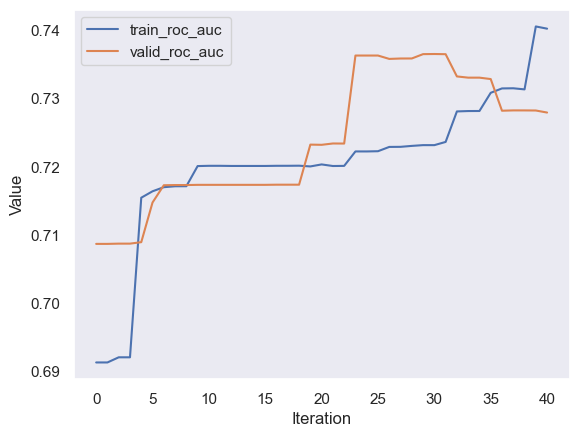

In [33]:
boosting.plot_history(["train_roc_auc", "valid_roc_auc"])

### 📌 2.2. Категории 2.0 (0.5 балла)

Пока что для простоты картины мы игнорировали категориальные признаки. <font color='#c4bf0a'>**CatBoost**</font> в частности предлагает один из самых эффективных и быстрых вариантов кодировки категорий, который мы попробуем повторить

> Основная идея в том, что важны не сами категории, а значения целевой переменной, которые имеют объекты этой категории. Каждый категориальный признак мы заменим средним значением целевой переменной по всем объектам этой же категории:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)]}
$$


Добавьте в модель вот это:
- `cat_features: Iterable | None` — категориальные признаки для кодирования
- `_cat_fit(self, X: np.array, y: np.ndarray)` — внутренний метод для построения счетчиков
- `_cat_transform(self, X: np.ndarray)` — внутренний метод для применения счетчиков

Лмбо сделайте энкодер отдельным классом с аналогичными методами `fit` и `transform`, это даже лучше. Его нужно прогнать всего раз для каждой из выборок

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>-</code></td>
<td align="center"><code>-</code></td>
<td align="center"><code>cat_features</code></td>
</tr>
</table>

</div>

Закодируйте переменные, которые вы хотите считать категориальными, с помощью счётчиков (готовые реализации брать нельзя) и покажите эффект. Помните, что все должно быть векторизовано и красиво

In [4]:
# вернем occupation туда, где ему самое место, но это не единственная кат фича!

X_train = X[X["year"] < 2011].values
X_valid = X[X["year"] == 2011].values
X_test = X[X["year"] == 2013].values

In [6]:
occ_idx = X.columns.get_loc("occupation")
empstat_idx = X.columns.get_loc("empstat")
race_idx = X.columns.get_loc("race")

boosting_cat = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=[occ_idx, empstat_idx, race_idx],
)

boosting_cat.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

100%|██████████| 50/50 [12:31<00:00, 15.03s/it]


In [7]:
print(f"Train ROC-AUC: {boosting_cat.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting_cat.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC: {boosting_cat.score(X_test, y_test):.4f}")

Train ROC-AUC: 0.8157
Valid ROC-AUC: 0.7749
Test ROC-AUC: 0.7703


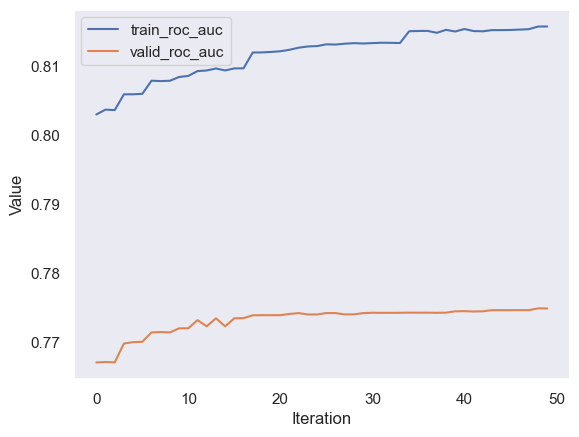

In [8]:
boosting_cat.plot_history(["train_roc_auc", "valid_roc_auc"])

### 💠 2.3. Категории 3.0 (0.5 балла)

Увы, закодированные признаки сами по себе являются классификаторами и, обучаясь на них, мы допускаем утечку целевой переменной в признаки, но с этим можно жить, в частности $\text{OrderedBoosting}$ это одна из главных фишек <font color='#c4bf0a'>**CatBoost**</font>, была. Почитайте [статью](https://arxiv.org/pdf/1706.09516), она интересная

Реализуйте подсчет счетчиков так, чтобы кодировка категории была только по объектам. расположенным выше в датасете (например, если выборка отсортирована каким-либо образом)

Методы добавлять не нужно, разве что очень хочется, предполагается, что это дефолтное поведение бустинга

In [13]:
rand = np.random.RandomState(69)
perm = rand.permutation(X_train.shape[0])

X_train_ordered = X_train[perm]
y_train_ordered = y_train[perm]

occ_idx = X.columns.get_loc("occupation")
empstat_idx = X.columns.get_loc("empstat")
race_idx = X.columns.get_loc("race")

boosting_cat_ordered = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=[occ_idx, empstat_idx, race_idx],
    cat_order=True
)

boosting_cat_ordered.fit(
    X_train_ordered,
    y_train_ordered,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

 70%|███████   | 35/50 [09:59<04:16, 17.13s/it]


In [14]:
print(f"Train ROC-AUC: {boosting_cat_ordered.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting_cat_ordered.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC: {boosting_cat_ordered.score(X_test, y_test):.4f}")

Train ROC-AUC: 0.8130
Valid ROC-AUC: 0.7742
Test ROC-AUC: 0.7692


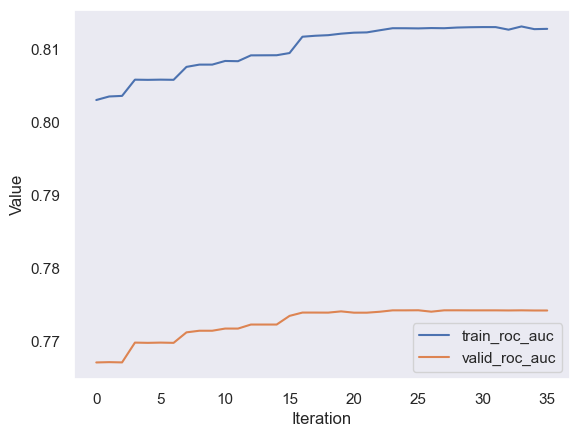

In [15]:
boosting_cat_ordered.plot_history(["train_roc_auc", "valid_roc_auc"])

### 💠 2.4. Категории 4.0, L2 и боль (2 балла)

Но погодите, вы ещё ничего не видели! Счётчики это замечательный способ кодирования категорий, но у них есть ровно один недостаток — после кодировки признаки становятся числовыми, а если вы помните дз5, категориальные и числовые признаки обрабатываются деревьями чуть-чуть иначе.

<font color="#53c96c">**LightGBM**</font> и <font color="#2f82d4">**XGBoost**</font> решают этот вопрос не так, как <font color='#c4bf0a'>**CatBoost**</font>. Сейчас будем разбираться... И будет это тяжело, потому что отдебажить это не получится вплоть до самого конца.

Для этого пункта вам придётся стряхнуть пыль с вашей [реализации дерева](https://github.com/esokolov/ml-course-hse/blob/master/ml1-2026-spring/homework-practice/homework-practice-05-trees/hw5code.py) из дз5. Будем верить, что она написана красиво и хорошо масштабируется на новые МЛьные приключения.

#### 2.4.1. Настоящий критерий информативности (0.5 балла)

Современные реализации бустинга не используют дефолтные критерии информативности, вроде энтропии или дисперсии. Параметр `gamma`, который за нас любезно подбирается в классе `Boosting` это немного устаревший способ выбора весов (лет так на 25).

На лекции обсуждается, что получить формулу для обучения нового дерева $b_n(x)$ можно, если разложить исходную задачу обучения бустинга в ряд Тейлора. Там же показано, что при обучении на один лишь сдвиг $s_i(x)$ мы полагаем кривизну $h_i(x) = \frac{\partial^2 L}{\partial z^2}$ константной. Но можем и не полагать, как [сделали](https://arxiv.org/pdf/1603.02754) авторы уже немолодого <font color="#2f82d4">**XGBoost**</font>.

Критерий информативности в таком случае имеет вид:

$$
H(R_m) = \frac{G_l^2}{H_l + \lambda} + \frac{G_r^2}{H_r + \lambda} - \frac{G_m^2}{H_m + \lambda}
$$

- $G$ — сумма градиентов
- $H$ — сумма гессианов
- $\lambda$ — коэффициент регуляризации
- индексы $_l$, $_r$, $_m$ — левый, правый, исходный узел дерева соответственно

> Кривизна позволяет нам подстроиться под каждый объект, когда мы делаем шаг градиентного бустинга. $\gamma$ в таком случае оказывается не нужна, она не умеет подстраивать шаг индивидуально. Более того, сюда можно сразу же встроить $L_2$ регуляризацию, что мы и сделаем.     
Наконец, если перейти от объектов к градиентам и гессианам, внезапно можно вообще забить на то, числовой признак или категориальный, мы же всё равно оцениваем градиент, то есть сплит подбираем напрямую из задачи. Велико!

Текущая задача: модифицировать функцию `find_best_split`. Считайте, что параметры `grad_vector` и `hess_vector` в неё уже передаются. Градиент мы считать уже умеем, с гессианом разберёмся попозже

In [ ]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓

#### 2.4.2. Я посадил дерево (0.75 балла)

Теперь, когда критерий у нас есть, наступает следующий логический шаг - пихнуть его в дерево. Предсказания будут иметь следующий вид:

$$b(R) = \frac{1}{|R|}\sum_{y_i \in R} \frac{\nabla(y_i)}{(\nabla^2(y_i) + \lambda )}$$

Это сумма градиентов делить на сумму гессианов + коэффициент регуляризации. В случае $\nabla^2(y_i) = 1$ и нулевой регуляризации вырождается в наш самый обыкновенный бустинг. Мы ведь помним, что каждое дерево в нём обучается на антиградиент.

Что делать то?

- добавить параметр `l2: float | None = 1.0` в вашу реализацию дерева
- подправить предсказания по формуле выше, сейчас они считаются для классификации, а не для регрессии (должно быть идентично и для чисел, и для категорий)
- категории нужно занумеровать, это делается за вас в дереве, но не забудьте пожалуйста
- в `fit_node` должны поступать градиенты и гессианы, в левый и правый узел после разбиения тоже, уже для соответствующих левой и правой подвыборок

> Строго говоря, <font color="#53c96c">**LightGBM**</font> перебирает категории по критерию Фишера, который группирует категории по градиентам. Это один из видов квантизации, которая будет чуть ниже. Делать это не надо, но если любопытно, то [почитайте](https://lightgbm.readthedocs.io/en/latest/Features.html#optimal-split-for-categorical-features)

In [ ]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓

#### 2.4.3. Момент истины (0.75 балла)

Наконец, осталось запихнуть это дело в бустинг. Алгоритм будет работать точно так же. Если вы корректно его написали, поменять потребуется немного, а именно:

- добавить гиперпараметр `l2: float | None = 0.0`
- добавить метод `self.hess_fn = lambda y, z: ...`, который будет считать гессиан для бинарной кросс-энтропии
- приравнять оптимальную гамму к единице, если `l2` не равен 0
- передавать гредиенты и гессианы в базовую модель, если у неё есть параметр `l2` и он не равен 0
- гессиан лучше клипать, иначе можно внезапно поделить на 0 при маленьком `l2`
- не забудьте, что передавать надо антиградиенты, а не просто градиенты, иначе выйдет что-то не то

Покажите, что оно работает...

In [ ]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓

### 💠 2.5. Бутстрап (1.25 балла)</span>

Как известно, при обучении базовых алгоритмов в беггинге, используется бутстрапированная выборка. Звучит хайпово, почему бы не попробовать сделать то же самое в бустинге?

> Идея, которая за этим стоит проста — бустинги переобучаются, как черти. Бутстрап же может сделать процесс куда более робастным и быть одним из способов регуляризации, а заодно уменьшить время обучения, в случае бутстрапа Бернулли

#### 2.5.1. Бутстрап дефолтный (0.75 балла)

Вам нужно реализовать параметры:
- `subsample: float = 1.0` — доля объектов, на которой будет обучаться базовая модель (какую часть составляет бутстрапная выборка от исходной обучающей). Соответствует бутстрапу типа `Bernoulli`. Каждый объект либо входит в подвыборку, либо нет
- `bagging_temperature: float = 1.0` — температура для генерации весов. Соответствует бутстрапу типа `Bayesian`. Каждому объекту присваивается вес $w$, который получается из температуры $t$, после чего объект, в количестве $w$, попадает в выборку.      
$w = (-\log(X))^t$, где $X \sim {U[0, 1]}$      
Таким образом можно сделать симуляцию повторений, обобщив на непрерывный случай. Обычный бутстрап не умеет сэмплировать дробное число объектов, но можно сделать примерно то же самое, если размножить объект $w$ раз, либо присвоить вес. Подумайте, как это корректно реализовать в бустинге
- `bootstrap_type: str | None = 'Bernoulli'` — тип бутстрапа

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>subsample</code>, <code>-</code></td>
<td align="center"><code>subsample</code>, <code>bagging</code></td>
<td align="center"><code>subsample</code>, <code>bootstrap_type</code></td>
</tr>
</table>

</div>

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бутстрап может помочь в обучении с точки зрения смещения, разброса и вообще?

**Ответ:**
Бутстрап должен уменьшить разброс, потому что результат суммирования моделей, ещё и несильно коррелированных, что довивается элементом рандома бустрапа, является более устойчивым. При этом смещение не увеличичвается, или увеличивается, но незначительно.

</div>

Сначала обучим модель для бустрапа типа Бернулли:

In [22]:
boosting_bootstrap = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=[occ_idx, empstat_idx, race_idx],
    cat_order=True,
    bootstrap_type="Bernoulli",
    subsample=0.8,
)

boosting_bootstrap.fit(
    X_train_ordered,
    y_train_ordered,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

 76%|███████▌  | 38/50 [06:44<02:07, 10.64s/it]


In [23]:
print(f"Train ROC-AUC: {boosting_bootstrap.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting_bootstrap.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC: {boosting_bootstrap.score(X_test, y_test):.4f}")

Train ROC-AUC: 0.8131
Valid ROC-AUC: 0.7743
Test ROC-AUC: 0.7693


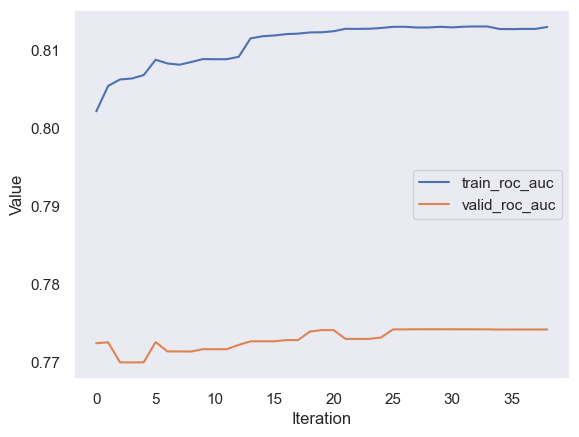

In [39]:
boosting_bootstrap.plot_history(["train_roc_auc", "valid_roc_auc"])

Теперь то же самое, но для типа Байеса:

In [25]:
boosting_bootstrap_2 = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=[occ_idx, empstat_idx, race_idx],
    cat_order=True,
    bootstrap_type="Bayesian",
    bagging_temperature=1.0,
)

boosting_bootstrap_2.fit(
    X_train_ordered,
    y_train_ordered,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

 24%|██▍       | 12/50 [00:57<03:01,  4.77s/it]


In [26]:
print(f"Train ROC-AUC: {boosting_bootstrap_2.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting_bootstrap_2.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC: {boosting_bootstrap_2.score(X_test, y_test):.4f}")

Train ROC-AUC: 0.8078
Valid ROC-AUC: 0.7757
Test ROC-AUC: 0.7705


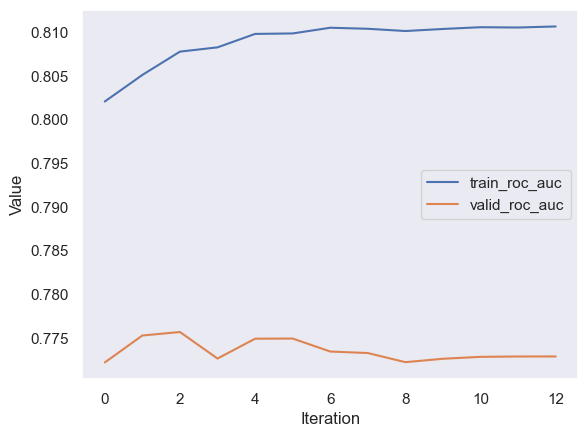

In [38]:
boosting_bootstrap_2.plot_history(["train_roc_auc", "valid_roc_auc"])

Помимо выбора случайных объектов, есть идея выбирать случайное подмножество признаков, заложенная в Random Forest. Мотивация это делать точно та же самая, что и в бутстрапировании, за это будет отвечать параметр `rsm`

В библиотеках это реализовано так:

<div align="center">

| <font color="#2f82d4">XGBoost</font> | <font color="#41a657">LightGBM</font> | <font color='#d1cd3b'>CatBoost</font> |
| :---: | :---: | :---: |
| `colsample_bytree`| `colsample_bytree`| `rsm`|

</div>

Нужно добавить параметр:
- `rsm: float = 1.0` — доля признаков, участвующих в обучении модели. Каждый признак либо входит, либо не входит в пул, на котором обучается базовый алгоритм, по аналогии с бутстрапом Бернулли

In [30]:
boosting_rsm = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=[occ_idx, empstat_idx, race_idx],
    cat_order=True,
    bootstrap_type="Bayesian",
    bagging_temperature=1.0,
    rsm=0.8
)

boosting_rsm.fit(
    X_train_ordered,
    y_train_ordered,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

100%|██████████| 50/50 [08:09<00:00,  9.78s/it]


In [31]:
print(f"Train ROC-AUC: {boosting_rsm.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting_rsm.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC: {boosting_rsm.score(X_test, y_test):.4f}")

Train ROC-AUC: 0.8206
Valid ROC-AUC: 0.7763
Test ROC-AUC: 0.7714


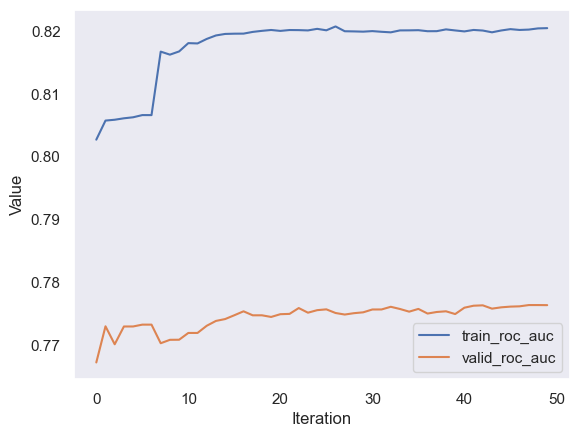

In [37]:
boosting_rsm.plot_history(["train_roc_auc", "valid_roc_auc"])

#### 2.5.2. GOSS (0.5 балла)

Заметим, что во время обучения не все объекты одинаково важны. Один из вариантов это исправить — ввести какие-то веса на объекты, однако можно пойти чуть хитрее. В <font color='#53c96c'>**LightGBM**</font> придумали подход [Gradient-based One-side Sampling](https://www.microsoft.com/en-us/research/wp-content/uploads/2017/11/lightgbm.pdf)

> Давайте оценивать важность объектов в отдельный момент обучения нового дерева. Будем считать, какой антиградиент привносит каждый объект. Далее разобьем градиенты на 2 группы. Объекты с большими (по модулю) градиентами берутся все, с маленькими — только часть, по аналогии с бутстрапом. И не забываем домножить на фактор, чтобы учесть выкинутые объекты. Подробнее в статье

Параметры, которые нужно сделать:

- `goss: bool = False` — GOSS бустинг или нет
- `goss_k: float = 0.2` — доля объектов, градиенты которых будем считать большими. Все остальное — маленькими
- `subsample: float = 0.3` — параметры сэмплинга Бернулли для маленьких градиентов из пункта 2.3

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>-</code></td>
<td align="center"><code>bagging='goss'</code></td>
<td align="center"><code>bootstrap_type='MVS'</code></td>
</tr>
</table>

</div>

Сделайте и посмотрите

In [34]:
boosting_goss = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=[occ_idx, empstat_idx, race_idx],
    cat_order=True,
    goss=True,
    goss_k=0.2,
    subsample=0.3
)

boosting_goss.fit(
    X_train_ordered,
    y_train_ordered,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

 72%|███████▏  | 36/50 [10:15<03:59, 17.10s/it]


In [35]:
print(f"Train ROC-AUC: {boosting_goss.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting_goss.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC: {boosting_goss.score(X_test, y_test):.4f}")

Train ROC-AUC: 0.8188
Valid ROC-AUC: 0.7787
Test ROC-AUC: 0.7738


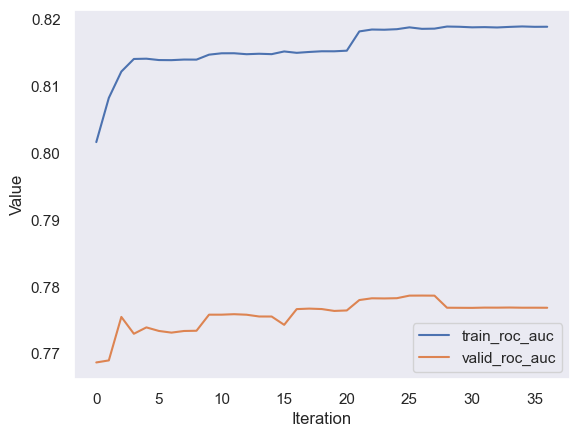

In [36]:
boosting_goss.plot_history(["train_roc_auc", "valid_roc_auc"])

### 💠 2.6. Бинаризация (1 балл)

Вместо того, чтобы выкидывать признаки, можно попробовать проредить их множество значений, применив бинаризацию. В идеале это стоит делать с датасетом до обучения модели, но не обязательно, можно, например, на этапе `fit`, а в `partial_fit` приходит уже квантизованный датасет.

> Зачем это? Да все очень просто! Квантизованные данные весят гораздо меньше, значений в них куда как меньше, а значит, наше обучение пойдет гораздо быстрее, к тому же все снова станет устойчивее.        
Беда лишь в новых данных, которые могут оказаться вне бина, но великие силы избавили нас от этих проблем в нашем датасете. Фактически мотивация вновь та же, что у бутстрапа

#### 2.6.1. Простейшие стратегии (0.5 балла)

Нужно добавить параметры:
- `quantization_type: str | None = None` — тип квантизации, если она есть
- `nbins: int = 255` — число бинов для квантизации. Игнорируем, если тип квантизации не указан

Либо сделать квантизатор отдельным классом, где в `fit` запоминаются пороги, а в `transform` преобразуются фичи

Рассмотрим варианта `quantization_type`:

- `'uniform'` — значения признака $[\min f_i, \max f_i]$ отображаются в `nbins` отрезков одинаковой длины, которые полностью покрывают интервал
- `'quantile'` — тот же самый отрезок сортируется и бьется на `nbins` квантилей от 0 до 1

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>tree_method</code></td>
<td align="center"><code>max_bin</code></td>
<td align="center"><code>quantize(...)</code></td>
</tr>
</table>

</div>

Разницу между ними вы можете увидеть на картинке, где квантизуется гауссиана

<img src="https://i.postimg.cc/gJ2SJgpN/image-2025-11-29-201502496.png" height=300>

Реализуйте их, примените их к числовым признакам, и покажите, что все работает четко

In [9]:
region_idx = X.columns.get_loc("region")
race_idx = X.columns.get_loc("race")
empstat_idx = X.columns.get_loc("empstat")
occupation_idx = X.columns.get_loc("occupation")

features = [region_idx, race_idx, empstat_idx, occupation_idx]

Обучим модель с бинаризацией типа `uniform`:

In [22]:
boosting_uniform = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=features,
    cat_order=True,
    goss=True,
    goss_k=0.2,
    quantization_type="uniform",
    nbins=20
)

boosting_uniform.fit(
    X_train_ordered,
    y_train_ordered,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

 96%|█████████▌| 48/50 [01:39<00:04,  2.06s/it]


In [23]:
print(f"Train ROC-AUC: {boosting_uniform.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting_uniform.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC: {boosting_uniform.score(X_test, y_test):.4f}")

Train ROC-AUC: 0.8079
Valid ROC-AUC: 0.7915
Test ROC-AUC: 0.7875


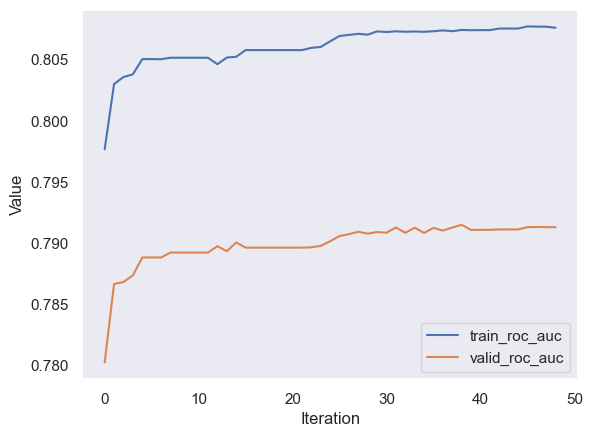

In [24]:
boosting_uniform.plot_history(["train_roc_auc", "valid_roc_auc"])

Обучим модель с бинаризацией типа `quantile`:

In [15]:
boosting_quant = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=features,
    cat_order=True,
    goss=True,
    goss_k=0.2,
    subsample=0.3,
    quantization_type="quantile",
    nbins=20
)

boosting_quant.fit(
    X_train_ordered,
    y_train_ordered,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

 34%|███▍      | 17/50 [00:22<00:42,  1.29s/it]


In [16]:
print(f"Train ROC-AUC: {boosting_quant.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting_quant.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC: {boosting_quant.score(X_test, y_test):.4f}")

Train ROC-AUC: 0.8136
Valid ROC-AUC: 0.7753
Test ROC-AUC: 0.7701


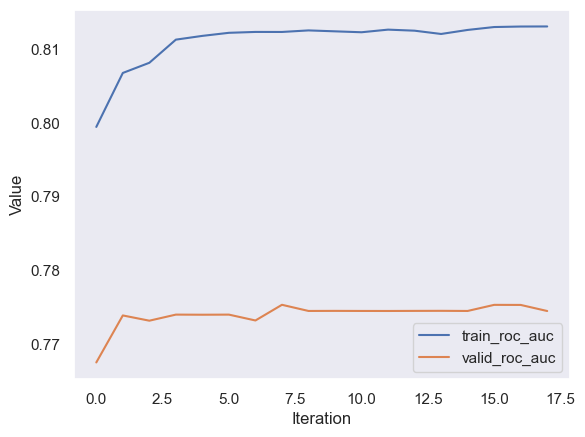

In [17]:
boosting_quant.plot_history(["train_roc_auc", "valid_roc_auc"])

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как квантизация поможет в обработке выбросов и нанов?

**Ответ:**
Квантизация уменьшает влияние выбросов, потому что очень большие значения попадают в один и тот же крайний бин. С нанами тоже помогает, потому что скорее всего дерево выделит для них отдельных бин, и пропуски будут обрабатываться отдельно.

</div>

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можно ли просто заполнить наны каким-то числом? Имеет ли значение, что это за число (-1, -100, -1e32)?

**Ответ:**
Да, можно, но чтобы эти данные не перепутались с реальными данными, и чтобы в последствии объекты с пропусками выделились в одельный бин, лучше их заполнить очень маленьким значением.

</div>

#### 2.6.2. Квантизация (0.5 балла)

В современных имплементациях бустинга используются более сложные методы квантизации. К сожалению, способы выше страдают либо от неравноправности бинов — в каких-то объектов больше, в каких-то меньше, в каких-то значения повторяются, в каких-то нет, либо от того, что целевая переменная от бинов зависит опосредованно, да и пороги берутся с потолка

Есть два необычных, но крайне интересных подхода:

1. $\text{MinEntropy}$. Это [один из методов](https://catboost.ai/docs/en/concepts/quantization), который используется для бинаризации в <font color='#c4bf0a'>**CatBoost**</font>, остальные на него очень похожи. Будем жадно набирать бины так, чтобы суммарная побиновая энтропия объектов ($\sum_{i \in \text{bin}} x_i\log(x_i)$) была как можно меньше. Это, правда, предполагает, что значения числовых фичей могут повторяться, и так и есть в части наших колонок
   
2. $\text{PiecewiseEncoding}$. Это относительно свежий метод для [табличных трансформеров](https://arxiv.org/pdf/2203.05556). Суть заключается в том, что бины для квантизации будем брать не с потолка, а именно те, что нужны для разбиения таргета через максимизацию $\text{InfoGain}$

Оба метода на самом деле похожи, поэтому выбирайте на свой вкус. Оба пытаются подобрать пороги при помощи некоторого алгоритма, который тоже работает с энтропией или InfoGain, возможно, вы его даже знаете, осталось правильно его применить. В библиотеках способы реализации чуть отличаются, и предлагаемый способ не единственный. Если есть желание - экспериментируйте!

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>-</code></td>
<td align="center"><code>-</code></td>
<td align="center"><code>feature_border_type="Piecewise"</code></td>
</tr>
</table>

</div>

Добавьте одну из опций, `'min_entropy'` или `'piecewise'`, для `quantization_type` и покажите, что оно работает

Я выбрала `piecewise`:

In [19]:
boosting_piecewise = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=features,
    cat_order=True,
    goss=True,
    goss_k=0.2,
    subsample=0.3,
    quantization_type="piecewise",
    nbins=20
)

boosting_piecewise.fit(
    X_train_ordered,
    y_train_ordered,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

 26%|██▌       | 13/50 [00:18<00:52,  1.42s/it]


In [20]:
print(f"Train ROC-AUC: {boosting_piecewise.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting_piecewise.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC: {boosting_piecewise.score(X_test, y_test):.4f}")

Train ROC-AUC: 0.8118
Valid ROC-AUC: 0.7755
Test ROC-AUC: 0.7702


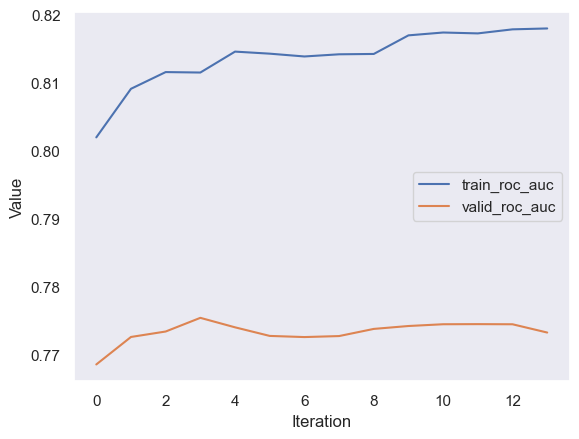

In [25]:
boosting_piecewise.plot_history(["train_roc_auc", "valid_roc_auc"])

### 💠 2.7. Важность дерева (0.5 балла)

Поскольку наша базовая модель — это дерево из `sklearn`, мы можем вычислить важность признака отдельно для каждого дерева и взвешенно усреднить (воспользуйтесь `feature_importances_` у `DecisionTreeRegressor` и знанием о гаммах), после этого нормировать значения, чтобы они суммировались в единицу (обратите внимание, что они должны быть неотрицательными — иначе вы что-то сделали не так).

> Как правило, этот способ учитывает, сколько раз та или иная фича использовалась для сплита. Чем больше раз, тем этот признак важнее

Допишите к бустингу:
- `get_feature_importance(self, X: np.ndarray | None = None, y: np.ndarray | None = None, type="split")` — атрибут, который возвращает важность признаков, согласно методу выше

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>model.get_score()</code></td>
<td align="center"><code>lightgbm.importance()</code></td>
<td align="center"><code>model.get_feature_importance()</code></td>
</tr>
</table>

</div>

Покажите, какие признаки оказались самыми важными

In [9]:
boosting_piecewise = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=features,
    cat_order=True,
    goss=True,
    goss_k=0.2,
    subsample=0.3,
    quantization_type="piecewise",
    nbins=20
)

boosting_piecewise.fit(
    X_train_ordered,
    y_train_ordered,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

 26%|██▌       | 13/50 [00:34<01:37,  2.64s/it]


In [11]:
importances = boosting_piecewise.get_feature_importance(X_train_ordered)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
10,occupation,0.943186
8,hrwage,0.023785
7,annhrs,0.021082
9,incwage,0.009533
4,sch,0.002413
0,region,0.000000
1,age,0.000000
2,year,0.000000
6,occ,0.000000
3,race,0.000000


### 💠 2.8. Важность бустинга (1 балл)

Но бустинг и дерево это, как говорится, две большие разницы. Дерево ничего не знает про лосс, оно учится по другим соображениям, которые на самом деле не так важны. И как оказывается, это влияние на лосс можно оценить.

> Проблема предыдущего способа в том, что мы не учитываем, насколько сплит реально помогает в решении задачи минимизации функции потерь. Но зная лосс, а точнее градиент, это можно элементарно оценить

Алгоритм будет такой:
1. Возьмём базовый эстимейтор $b_k$ (`sklearn.tree.DecisionTreeRegressor`)
2. Научимся доставать из него [путь](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html) для конкретного объекта $x_i$
3. В этом пути для каждого узла $R_j$ вытащим предсказание $b_k(R_j)(x_i)$ (это параметр `value`) и то, по какой фиче был сделан сплит
4. Для каждого предсказания запишем, на сколько уменьшился лосс (проще всего взять антиградиент, но можно взять критерий информативности из 2.4.1)
   
Повторить для всех деревьев, для всех объектов (или осмысленного их сабсэмпла)

Допишите к бустингу:
- `get_feature_importance(self, X: np.ndarray, y: np.ndarray, type="gain")` — атрибут, который возвращает важность признаков, согласно методу выше

Изменилось ли что-то в важности признаков?

In [17]:
from importlib import reload
import boosting

reload(boosting)

from boosting import Boosting

In [10]:
boosting_piecewise = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=features,
    cat_order=True,
    goss=True,
    goss_k=0.2,
    subsample=0.3,
    quantization_type="piecewise",
    nbins=20
)

boosting_piecewise.fit(
    X_train_ordered,
    y_train_ordered,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

 26%|██▌       | 13/50 [00:34<01:37,  2.63s/it]


In [11]:
importances_gain = boosting_piecewise.get_feature_importance(X_valid, y_valid, type="gain")

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances_gain
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
10,occupation,0.746731
7,annhrs,0.128452
8,hrwage,0.082129
9,incwage,0.030774
4,sch,0.011914
0,region,0.000000
1,age,0.000000
2,year,0.000000
6,occ,0.000000
3,race,0.000000


Важности и правда изменились: раньше признак `occupation` имел очень большую важность - больше 0.9, сейчас этот признак всё ещё самый важный, но его значение уменьшилось до 0.74, и остальный призаки стали оцениваться как чуть более важные. Но порядок признаков по важности практичнски не изменился.

### 💠 2.9. DART (1 балл)

Ранее мы обсуждали, что каждый базовый алгоритм пытается исправить ошибки всего предыдущего ансамбля. Из-за этого возникает неравноправие — каждая новая модель вносит все меньший и меньший вклад. Уверенные обучатели нейросетей знают, что это может привести к переобучению, если проводить аналогию с весами. Но выход есть, и выход этот [DART](https://arxiv.org/pdf/1505.01866)!

> В DL есть такой вид регуляризации, как dropout, когда некоторые узлы нейросети со случайным шансом отключаются. Можно попробовать обобщить этот подход на случай бустингов и случайно выкидывать деревья из композиции во время обучения

1. Выбираем, какие деревья убрать. При подсчете антиградиента берем не весь ансамбль, а только ту часть, что осталась
2. Домножаем выходы дерева на $1/k$, где $k$ — число удаленных деревьев, чтобы учесть тот факт, что ансамбль был не весь. Тогда вклад отдельного дерева будет не настолько большим
3. Домножаем выходы выкинутых деревьев на $k/(k+1)$, чтобы масштабы выходов примерно совпадали

Параметры, которые нужно добавить:

- `dart: bool = False` — DART бустинг или нет
- `dropout_rate: float = 0.05` — доля деревьев, которую выкидываем во время обучения DART

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>XGBClassifier(booster="dart")</code></td>
<td align="center"><code>LGBMClassifier(boosting_type="dart")</code></td>
<td align="center"><code>-</code></td>
</tr>
</table>

</div>

Попробуйте обучить DART на наших данных. Статью читать настоятельно рекомендуется, метод не самый простой

In [14]:
boosting_dart = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=features,
    cat_order=True,
    goss=True,
    goss_k=0.2,
    subsample=0.3,
    quantization_type="piecewise",
    nbins=20,
    dart=True,
    dropout_rate=0.05,
)

boosting_dart.fit(
    X_train_ordered,
    y_train_ordered,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

 62%|██████▏   | 31/50 [01:41<01:02,  3.27s/it]


In [15]:
print(f"Train ROC-AUC: {boosting_dart.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting_dart.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC: {boosting_dart.score(X_test, y_test):.4f}")

Train ROC-AUC: 0.8184
Valid ROC-AUC: 0.7759
Test ROC-AUC: 0.7710


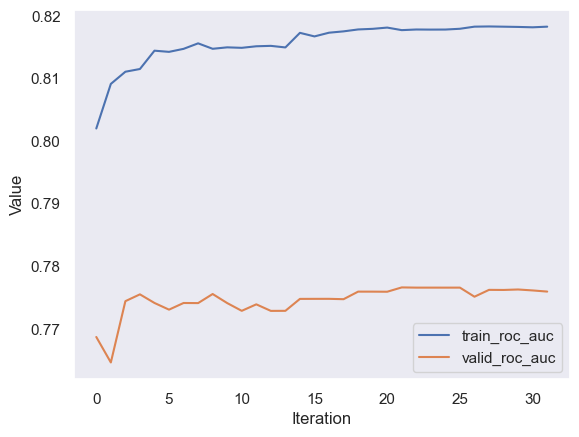

In [16]:
boosting_dart.plot_history(["train_roc_auc", "valid_roc_auc"])

### 💠 2.10. Бустинг линейных моделей (0.5 балла)

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что произойдет при ансамблировании линейных моделей? Имеет ли это смысл?

**Ответ:**

</div>

Давайте убедимся. Обучите бустинг, где в качестве базовой модели будет линейная регрессия. Обязательно сохраните историю функции потерь и зафиксируйте время обучения. Можно взять уже готовый из <font color='#2f82d4'>**XGBoost**</font>, но будьте готовы разобраться с тем, как оттуда достать историю обучения

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>XGBClassifier(booster="gblinear")</code></td>
<td align="center"><code>-</code></td>
<td align="center"><code>-</code></td>
</tr>
</table>

</div>

In [ ]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓

Теперь возьмите `sklearn.linear_model.SGDClassifier` и обучите на тех же данных. Не забудьте понять, как вытащить оттуда историю функции потерь

In [ ]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓

Покажите на одном графике изменение функции потерь для бустинга и SGD классификатора. Сравните следующие детали у бустинга и линейной модели:

- время обучения
- сходимость (как быстро, как стабильно и прочее)
- графики функции потерь на трейне и на валидации

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Какой вывод вы можете сделать?

**Ответ:**

</div>

### 💠 2.11. Потери потерь (0.5 балла)

Если вы смотрели в датасет, то вероятно заметили, что данные в нём несбалансированы. С этим можно жить, и этому вы научитесь на мо2, но нужно ли? Ведь всегда можно шлёпнуть простой советский проверенный способ, который в бустингах применяется не слишком широко, по непонятной, честно говоря, причине.

Смотрите, какая существует штука:

$$
\text{FocalLoss}(y, z) = -\frac{1}{n}\sum_{i=1}^{n} \left(1 - \sigma(y_i z_i)\right)^{\gamma} \log\!\big(\sigma(y_i z_i)\big)
$$

Что же это за покемон?
- параметр $\gamma$ (это другой гамма, свой, не бустинговый) регулирует, как сильно я акцентирую внимание на тех объектах, которых много, и которые легко разметить. Чем он больше, тем больше игнорим лёгкие примеры
- вес $(1 - \sigma(y_i z_i))$ регулирует вклад в лосс, в зависимости от класса
- в остальном это тот же логлосс

>Если разметить объект легко, то есть сигмоида даёт результат, близкий к единице, то нам как бы максимально всё равно, какой у него вклад в лосс, множитель под гаммой будет примерно 0, интереснее же на сложных примерах обучаться. А если сложно, то вклад напротив максимальный, объект полностью участвует в расчёте лосса

Хочется увидеть в классе `Boosting`:
- `loss: str = 'BCE` — лосс, на который обучаем бустинг, по дефолту `'BCE'` - бинарная кросс-энтропия, aka логистическая функция потерь
- `focal_gamma: float = 2.0` — гиперпараметр для силы фокал лосса, чем-то похож на `class_weights`, но поинтереснее
- методы `loss_fn` и `grad_fn` для фокал лосса

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>objective="custom"</code></td>
<td align="center"><code>objective="custom"</code></td>
<td align="center"><code>loss_function="FocalLoss"</code></td>
</tr>
</table>

</div>

Получилось? Покажите. Должно было стать чуть получше

In [21]:
boosting_focal = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=3),
    n_estimators=50,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=features,
    cat_order=True,
    quantization_type="uniform",
    nbins=20,
    loss="Focal",
    focal_gamma=2.0,
)

boosting_focal.fit(
    X_train_ordered,
    y_train_ordered,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

 78%|███████▊  | 39/50 [02:15<00:38,  3.46s/it]


In [22]:
print(f"Train ROC-AUC: {boosting_focal.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC: {boosting_focal.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC: {boosting_focal.score(X_test, y_test):.4f}")

Train ROC-AUC: 0.8075
Valid ROC-AUC: 0.7912
Test ROC-AUC: 0.7868


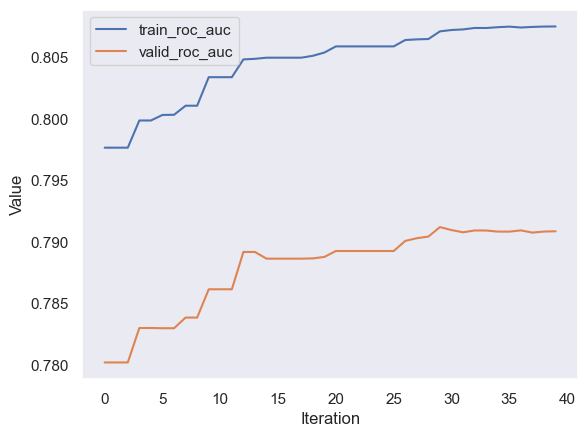

In [23]:
boosting_focal.plot_history(["train_roc_auc", "valid_roc_auc"])

------

## Задание 3. Около бустинга (📌 1 балл |💠 1.25 балла)

Теперь давайте проанализируем, как же правильно готовить бустинги. Нас интересует: как тюнить бустинги, какие они вообще бывают и как их интерпретировать. Посмотрим на все это по порядку

### 📌 3.1. Optuna наносит ответный удар (0.5 балла)

Если вы помните, у нас уже было знакомство с библиотекой `optuna` для подбора гиперпараметров. Вспомним, как это делается и подумаем, как это можно делать еще лучше

Подберите на валидации оптимальные значения следующих гиперпараметров для вашей реализации бустинга:
- `max_depth`
- `n_estimators`
- `learning_rate`
- любые другие, которые вы сделали в части 2

Подберите диапазон параметров самостоятельно, не забывайте фиксировать сид (нет, его не нужно перебирать). Сохраните и покажите оптимальный набор параметров. Покажите, какие из них дали наибольший прирост.

In [24]:
import optuna

def objective(study, model="custom_boosting"):

    boosting_params = {
        "n_estimators": study.suggest_int("n_estimators", 30, 100),
        "learning_rate": study.suggest_float("learning_rate", 0.02, 0.1),
        "quantization_type": "uniform",
        "nbins": study.suggest_int("nbins", 15, 50),
        "loss": "Focal",
        "focal_gamma": study.suggest_float("focal_gamma", 0.5, 5.0),
        "dart": True,
        "dropout_rate": study.suggest_float("dropout_rate", 0.02, 0.1),
        "random_state": 69,
        "verbose": False,
        "early_stopping_rounds": 10,
        "eval_metric": "valid_roc_auc",
        "cat_features": features,
        "cat_order": True,
    }

    tree_params = {"max_depth": study.suggest_int("max_depth", 3, 7)}

    bootstrap_type = study.suggest_categorical("bootstrap_type", ["Bernoulli", "Bayesian"])
    conditional_params = {"bootstrap_type": bootstrap_type}
    if bootstrap_type == "Bernoulli":
        conditional_params["subsample"] = study.suggest_float("subsample", 0.5, 1.0)
    if bootstrap_type == "Bayesian":
        conditional_params["bagging_temperature"] = study.suggest_float("bagging_temperature", 0.1, 5.0)

    boosting = Boosting(
        base_model_params=tree_params,
        **boosting_params,
        **conditional_params,
    )

    boosting.fit(
        X_train_ordered,
        y_train_ordered,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
    )

    return boosting.score(X_valid, y_valid)

In [26]:
study = optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=20, show_progress_bar=True)

print(study.best_params)
print(study.best_value)

[I 2026-05-28 14:12:39,216] A new study created in memory with name: no-name-1a8a4f44-796c-417c-b6b1-9062d7591a68
Best trial: 0. Best value: 0.798858:   5%|▌         | 1/20 [00:42<13:31, 42.70s/it]

[I 2026-05-28 14:13:21,919] Trial 0 finished with value: 0.7988575454881682 and parameters: {'n_estimators': 53, 'learning_rate': 0.048430898253108624, 'nbins': 18, 'focal_gamma': 3.0988501452750867, 'dropout_rate': 0.020103268672579385, 'max_depth': 6, 'bootstrap_type': 'Bayesian', 'bagging_temperature': 1.6596836248757192}. Best is trial 0 with value: 0.7988575454881682.


Best trial: 0. Best value: 0.798858:  10%|█         | 2/20 [01:27<13:12, 44.03s/it]

[I 2026-05-28 14:14:06,882] Trial 1 finished with value: 0.7952703284190845 and parameters: {'n_estimators': 49, 'learning_rate': 0.046678096072160155, 'nbins': 17, 'focal_gamma': 3.899837139854356, 'dropout_rate': 0.05670427492454086, 'max_depth': 5, 'bootstrap_type': 'Bayesian', 'bagging_temperature': 1.6297013248387922}. Best is trial 0 with value: 0.7988575454881682.


Best trial: 2. Best value: 0.806065:  15%|█▌        | 3/20 [03:09<19:56, 70.39s/it]

...

[I 2026-05-28 14:48:20,343] Trial 17 finished with value: 0.8022504457609311 and parameters: {'n_estimators': 87, 'learning_rate': 0.08088243765549602, 'nbins': 33, 'focal_gamma': 2.496808588434579, 'dropout_rate': 0.04836952764011285, 'max_depth': 7, 'bootstrap_type': 'Bernoulli', 'subsample': 0.6934544602474906}. Best is trial 3 with value: 0.8104021075936971.


Best trial: 3. Best value: 0.810402:  95%|█████████▌| 19/20 [40:13<03:41, 221.87s/it]

[I 2026-05-28 14:52:52,703] Trial 18 finished with value: 0.7914410060605106 and parameters: {'n_estimators': 66, 'learning_rate': 0.06338316299399047, 'nbins': 29, 'focal_gamma': 3.3815792190478304, 'dropout_rate': 0.07829325947179892, 'max_depth': 4, 'bootstrap_type': 'Bernoulli', 'subsample': 0.5079508736553617}. Best is trial 3 with value: 0.8104021075936971.


Best trial: 3. Best value: 0.810402: 100%|██████████| 20/20 [41:01<00:00, 123.06s/it]

[I 2026-05-28 14:53:40,480] Trial 19 finished with value: 0.8056815964105694 and parameters: {'n_estimators': 99, 'learning_rate': 0.03712219218417509, 'nbins': 45, 'focal_gamma': 4.344696415438566, 'dropout_rate': 0.06232020076474194, 'max_depth': 6, 'bootstrap_type': 'Bernoulli', 'subsample': 0.6029234864062469}. Best is trial 3 with value: 0.8104021075936971.
{'n_estimators': 69, 'learning_rate': 0.03339264783550054, 'nbins': 48, 'focal_gamma': 3.290986486831667, 'dropout_rate': 0.03670716926138628, 'max_depth': 7, 'bootstrap_type': 'Bernoulli', 'subsample': 0.6380040661353855}
0.8104021075936971


In [30]:
print(f'ROC-AUC = {study.best_value:.4f}')

ROC-AUC = 0.8104


Выбейте ROC-AUC хотя бы 0.8, и можете двигаться дальше

### 📌 3.2. Готовые реализации (0.5 балла)

Библиотек для бустингов существует много, но активно используются лишь три. Вам предстоит попробовать их в деле, посмотреть на их уникальные фишки и понять, что вам нравится больше всего

Возьмите любую из популярных библиотек: <font color='#2f82d4'>**XGBoost**</font>, <font color='#53c96c'>**LightGBM**</font> или <font color='#c4bf0a'>**CatBoost**</font>.
Ваша задача — взять одну из них, подобрать те же оптимальные параметры, что и выше, а также вставить [прунер](https://optuna.readthedocs.io/en/stable/reference/pruners.html).

Идея прунера — не обучать бустинг до конца, если по истории валидации видно, что другие бустинги на этом этапе статистически лучше, для этого мы и делали `partial_fit`, но в готовые реализации его можно вставить при помощи CallBack, для этого придётся немножко погуглить. Это во-первых, заметно ускоряет процесс перебора гиперпарамтеров, во-вторых неявно регуляризует модельку

Цель — увидеть в логах оптуны `Trial.PRUNED`, это знак того, что прунер работает. Если вы этого не видите, вероятно, вы вставили его неправильно.

In [7]:
from catboost import CatBoostClassifier, Pool
from optuna.integration import CatBoostPruningCallback
from sklearn.metrics import roc_auc_score

cat_names = ["region", "race", "empstat", "occupation"]
cat_ind = [X.columns.tolist().index(col) for col in cat_names]
train_pool = Pool(X_train, y_train, cat_features=cat_ind)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_ind)
test_pool = Pool(X_test, y_test, cat_features=cat_ind)

def objective_catboost(trial):
    bootstrap_type = trial.suggest_categorical("bootstrap_type", ["Bernoulli", "Bayesian"])
    params = {
        "iterations": trial.suggest_int("iterations", 30, 100),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.1),
        "depth": trial.suggest_int("depth", 3, 7),
        "border_count": trial.suggest_int("border_count", 15, 50),
        "bootstrap_type": bootstrap_type,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "random_seed": 69,
        "verbose": False,
    }

    if bootstrap_type == "Bernoulli":
        params["subsample"] = trial.suggest_float("subsample", 0.5, 1.0)
    if bootstrap_type == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0.1, 5.0)

    prun = CatBoostPruningCallback(trial, "AUC")
    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=valid_pool, callbacks=[prun])
    prun.check_pruned()
    preds = model.predict_proba(valid_pool)[:, 1]
    return roc_auc_score(y_valid, preds)

In [9]:
import optuna

pruner = optuna.pruners.MedianPruner(n_warmup_steps=10)
study_cat = optuna.create_study(direction="maximize", pruner=pruner)
study_cat.optimize(objective_catboost, n_trials=20, show_progress_bar=True)

print("ROC-AUC:", study_cat.best_value)

[I 2026-05-28 15:17:12,289] A new study created in memory with name: no-name-ba0a83c1-9210-4454-b5ca-0620f67fdb28
Best trial: 0. Best value: 0.770718:   5%|▌         | 1/20 [00:04<01:29,  4.72s/it]

[I 2026-05-28 15:17:17,010] Trial 0 finished with value: 0.7707184055134645 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 55, 'learning_rate': 0.08802005880337957, 'depth': 6, 'border_count': 39, 'subsample': 0.6997161381944144}. Best is trial 0 with value: 0.7707184055134645.


Best trial: 0. Best value: 0.770718:  10%|█         | 2/20 [00:09<01:20,  4.47s/it]

[I 2026-05-28 15:17:21,305] Trial 1 finished with value: 0.7681778589762704 and parameters: {'bootstrap_type': 'Bayesian', 'iterations': 44, 'learning_rate': 0.039664766586271605, 'depth': 7, 'border_count': 40, 'bagging_temperature': 4.254573701001926}. Best is trial 0 with value: 0.7707184055134645.


Best trial: 2. Best value: 0.779327:  15%|█▌        | 3/20 [00:13<01:17,  4.57s/it]

...

[I 2026-05-28 15:18:02,558] Trial 17 pruned. Trial was pruned at iteration 10.


Best trial: 5. Best value: 0.780628:  95%|█████████▌| 19/20 [00:53<00:02,  2.34s/it]

[I 2026-05-28 15:18:05,991] Trial 18 finished with value: 0.7775146653726657 and parameters: {'bootstrap_type': 'Bayesian', 'iterations': 62, 'learning_rate': 0.07291117378897768, 'depth': 3, 'border_count': 36, 'bagging_temperature': 0.11303807222063744}. Best is trial 5 with value: 0.7806276733358296.


Best trial: 5. Best value: 0.780628: 100%|██████████| 20/20 [00:54<00:00,  2.73s/it]

[I 2026-05-28 15:18:06,857] Trial 19 pruned. Trial was pruned at iteration 10.
ROC-AUC: 0.7806276733358296


<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Какая архитектура вам нравится больше всего и почему?

**Ответ:** Мне понравился `CatBoost`, так как удобно работать с категориальными признаками, не нужна была их сложная предварительная обработка. Также в этой бибилиотеке есть многие вещи, которые я делала в заданиях выше, типа OrderedBoosting и квантизация. Также это всё хорошо интегрируется с `optuna`.

</div>

### 💠 3.3. <font color='#2f82d4'>**XGBoost**</font> и велосипеды (0.25 баллов)

<font color='#2f82d4'>**XGBoost**</font> известен тем, что в нем впервые повилась регуляризация. Ручками ее написать сложно, и вы даже могли попробовать пунктом ранее, но зачем? Она уже написана, вообще-то. Вместо того, чтобы заниматься ерундой, можем попробовать импортировать и посмотреть, насколько она полезна в лучшем своём представлении.

Добавьте оба вида регуляризации, что там есть, как параметры в оптуну, и прогоните процесс оптимизации только на них.

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>alpha</code>, <code>lambda</code></td>
<td align="center"><code>lambda_l1</code>, <code>lambda_l2</code></td>
<td align="center"><code>-</code>, <code>l2_leaf_reg</code></td>
</tr>
</table>

</div>

In [ ]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Насколько регуляризация вообще эффективна?

**Ответ:**

</div>

### 💠 3.4. <font color='#53c96c'>**LightGBM**</font>, лес vs бустинг (0.25 балла)

<font color='#53c96c'>**LightGBM**</font> велик по многим причинам. В нём самое большое количество гиперпараметров из всех библиотек. А ещё он содержит в себе реализацию своего злейшего врага — случайный лес, это очень по-философски.

Посмотрите, какие есть параметры у него, обучите так сильно, как только сможете (не забудьте про свойства случайного леса к переобучению, про категориальные энкодеры и прочее).

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>num_parallel_tree</code></td>
<td align="center"><code>boosting_type="rf"</code></td>
<td align="center"><code>-</code></td>
</tr>
</table>

</div>

In [ ]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Кто победит: бустинг или лес? и почему?

**Ответ:**

</div>

### 💠 3.5. Еще пара красивых слов про <font color='#c4bf0a'>**CatBoost**</font> (0.25 балла)

<font color='#c4bf0a'>**CatBoost**</font> славится ещё и кучей разных подходов к обучению деревьев, в частности он умеет мёрджить несколько моделей в одно. Это не стекинг, и даже не беггинг, а совершенно другой уровень. Поскольку бустинги это уже некоторая сумма деревьев, ничего не мешает брать и складывать уже сами бустинги между собой.

 Попробуйте разбить выборку на фолды и обучить по катбусту на каждом из них, а затем их склеить. Тюнить их не надо, он и так неплох, в этом его сила и мудрость.

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>-</code></td>
<td align="center"><code>-</code></td>
<td align="center"><code>sum_models</code>, <code>to_classifier</code></td>
</tr>
</table>

</div>

Оцените, насколько это круто по 10-балльной

In [ ]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓

### 💠 3.6. Бустинг и вероятности (0.5 балла)

С качеством мы более-менее разобрались, но таки что насчет вероятностей? Постройте калибровочную кривую для вашей лучшей модели бустинга. Насколько хорошо бустинг оценивает вероятности?

In [ ]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓


Постройте также калибровочную кривую для логистической регрессии, сравните их между собой. Проанализируйте полученные результаты.

In [ ]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓

Конечно же, бустинг великолепен, как он есть, но можно сделать его еще лучше, если его откалибровать

1. Посмотрите на то, как это делать из библиотеки `sklearn`. Обратите внимание, передаете вы в него обученную модель или нет, а также на чем вы калибруетесь. Иначе есть риск что-то поломать
2. Откалибруйте вашу реализацию бустинга. Для этого за вас к нему был замешан `ClassifierMixin`
3. Покажите, как изменилась мера откалиброванности, для этого есть
$$\text{LogLoss} = -\frac{1}{N}\sum_{i} \sum_{k \in {0. 1}}\log p_k[y_i = k]; \qquad \text{BrierScore} = \frac{1}{N}\sum_{i} (p_i - y_i)^2;$$
4. Нарисуйте новую калибровочную кривую

In [ ]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Как вы можете прокомментировать то, что получилось?

**Ответ:**

</div>

## Музыкальный бонус. (0.5 балла) 🎶

В честь окончания весны исполните песню, которая больше всего ассоциируется у вас с МО-1, будь то Ольга Бузова, Валентин Стрыкало, Игорь Вихорьков, Глеб Смирнов или любой другой заслуженный артист. Одни, в бойз или гёрлз-бенде, вокально или инструментально (например, вашему вниманию представляется раритетнейшая [аранжировка](https://disk.360.yandex.ru/i/mY8spsw_d6abLA) на незабвенную классику за авторством Михаила Шелега), проявите фантазию. 